# 02 — Exploratory Data Analysis

Goals:
- Understand the structure and quality of the collected data
- Explore price seasonality and extreme events (negative prices, spikes)
- Explore household consumption patterns
- Understand correlation between weather and price/consumption

## 0. Imports & data loading

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA = '../../Data/'

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

WINTER = [12, 1, 2, 3]
SUMMER = [6, 7, 8, 9]

# One color per year (2022 → 2025)
COLORS = ['#4878cf', '#6acc65', '#d65f5f', '#b47cc7']

In [45]:
# ── Load electricity prices ───────────────────────────────────────────────────
# The raw file has mixed resolution: hourly (2022-2023) and 15-min (2024-2025).
# We resample to 1-hour averages so the whole dataset is consistent.
# We use price_eur_kwh (not MWh) — more intuitive for household context.

prices_raw = pd.read_csv(DATA + 'prices_be.csv')
prices_raw['timestamp'] = pd.to_datetime(prices_raw['timestamp'], utc=True)
prices_raw = prices_raw.set_index('timestamp').sort_index()

prices = prices_raw['price_eur_kwh'].resample('1h').mean().to_frame()
prices.index = prices.index.tz_convert('Europe/Brussels')

# Fill the 3 missing hours by linear interpolation between neighbours
prices['price_eur_kwh'] = prices['price_eur_kwh'].interpolate(method='time')

# Helper columns for grouping
prices['hour']       = prices.index.hour
prices['month']      = prices.index.month
prices['year']       = prices.index.year
prices['weekday']    = prices.index.dayofweek   # 0 = Monday, 6 = Sunday
prices['is_weekend'] = prices['weekday'] >= 5

print(f"Range:   {prices.index.min().date()} → {prices.index.max().date()}")
print(f"Rows:    {len(prices):,} hours | Missing after interpolation: {prices['price_eur_kwh'].isna().sum()}")

Range:   2022-01-01 → 2025-12-30
Rows:    35,040 hours | Missing after interpolation: 0


In [46]:
prices

,price_eur_kwh,hour,month,year,weekday,is_weekend
timestamp,,,,,,
2022-01-01 00:00:00+01:00,0.082020,0,1,2022,5,True
2022-01-01 01:00:00+01:00,0.067070,1,1,2022,5,True
2022-01-01 02:00:00+01:00,0.075110,2,1,2022,5,True
2022-01-01 03:00:00+01:00,0.050910,3,1,2022,5,True
2022-01-01 04:00:00+01:00,0.037670,4,1,2022,5,True
...,...,...,...,...,...,...
2025-12-30 19:00:00+01:00,0.105705,19,12,2025,1,False
2025-12-30 20:00:00+01:00,0.100318,20,12,2025,1,False
2025-12-30 21:00:00+01:00,0.092712,21,12,2025,1,False


In [47]:
# ── Load household consumption (H0 standard profile) ─────────────────────────
# H0 is the Belgian standard load profile for a typical household.
# Values are relative (not kWh directly) — the shape matters more than the level.

load_raw = pd.read_csv(DATA + 'load_profile.csv')
load_raw['timestamp'] = pd.to_datetime(load_raw['timestamp'])
load = load_raw.set_index('timestamp').sort_index()
load.columns = ['consumption']

load['hour']   = load.index.hour
load['month']  = load.index.month
load['year']   = load.index.year
load['season'] = load['month'].map(
    lambda m: 'Winter' if m in WINTER else ('Summer' if m in SUMMER else 'Transition')
)

# Trim to the same end date as prices (prices ends one day earlier)
price_end = prices.index.max().tz_localize(None)
load = load[load.index <= price_end]

print(f"Range: {load.index.min().date()} → {load.index.max().date()}")
print(f"Rows:  {len(load):,} hours")

Range: 2022-01-01 → 2025-12-30
Rows:  35,040 hours


In [48]:
# ── Scale H0 relative units → real kWh ───────────────────────────────────────
# Belgian household average: ~3500 kWh/year (Fluvius 2023).
# When real data arrives, replace this file with actual consumption (kWh)
# and remove the scaling below.

TARGET_KWH_YEAR = 3500
h0_annual  = load[load.index.year == 2022]['consumption'].sum()
LOAD_SCALE = TARGET_KWH_YEAR / h0_annual

load['consumption'] = load['consumption'] * LOAD_SCALE

print(f"Scale factor : {LOAD_SCALE:.4f}")
print(f"Annual total : {load[load.index.year == 2022]['consumption'].sum():.0f} kWh  (target {TARGET_KWH_YEAR})")
print(f"Mean hourly  : {load['consumption'].mean():.4f} kWh")

Scale factor : 1.0000
Annual total : 3500 kWh  (target 3500)
Mean hourly  : 0.3993 kWh


In [49]:
load

,consumption,hour,month,year,season
timestamp,,,,,
2022-01-01 00:00:00,0.234937,0,1,2022,Winter
2022-01-01 01:00:00,0.185279,1,1,2022,Winter
2022-01-01 02:00:00,0.147536,2,1,2022,Winter
2022-01-01 03:00:00,0.139126,3,1,2022,Winter
2022-01-01 04:00:00,0.134780,4,1,2022,Winter
...,...,...,...,...,...
2025-12-30 19:00:00,0.655890,19,12,2025,Winter
2025-12-30 20:00:00,0.589838,20,12,2025,Winter
2025-12-30 21:00:00,0.494231,21,12,2025,Winter


In [50]:
# ── Load weather data (Antwerp) ───────────────────────────────────────────────
weather = pd.read_csv(DATA + 'weather_antwerp.csv')
weather['timestamp'] = pd.to_datetime(weather['date'], utc=True)
weather = weather.drop(columns='date').set_index('timestamp').sort_index()
weather.index = weather.index.tz_convert('Europe/Brussels')
weather['month'] = weather.index.month
weather['hour']  = weather.index.hour

# Trim to the same end date as prices
weather = weather[(weather.index >= prices.index.min()) & (weather.index <= prices.index.max())]

print(weather.shape)
print(weather.dtypes)

(35040, 6)
temperature_2m         float64
cloud_cover            float64
wind_speed_10m         float64
shortwave_radiation    float64
month                    int32
hour                     int32
dtype: object


In [51]:
weather

,temperature_2m,cloud_cover,wind_speed_10m,shortwave_radiation,month,hour
timestamp,,,,,,
2022-01-01 00:00:00+01:00,12.40,100.0,17.429354,0.0,1,0
2022-01-01 01:00:00+01:00,12.65,100.0,14.618837,0.0,1,1
2022-01-01 02:00:00+01:00,11.45,100.0,15.546833,0.0,1,2
2022-01-01 03:00:00+01:00,10.90,28.0,15.778516,0.0,1,3
2022-01-01 04:00:00+01:00,10.45,72.0,15.294704,0.0,1,4
...,...,...,...,...,...,...
2025-12-30 19:00:00+01:00,1.65,100.0,8.951267,0.0,12,19
2025-12-30 20:00:00+01:00,2.25,100.0,7.689603,0.0,12,20
2025-12-30 21:00:00+01:00,2.45,100.0,7.467289,0.0,12,21


---
## 1. Price data — basic statistics

In [52]:
p = prices['price_eur_kwh'].dropna()

stats = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Min', 'Max', 'Std dev',
               'P5 (5th percentile)', 'P95 (95th percentile)',
               'Negative-price hours', 'Negative-price share'],
    'Value': [
        f"{p.mean():.4f} EUR/kWh",
        f"{p.median():.4f} EUR/kWh",
        f"{p.min():.4f} EUR/kWh",
        f"{p.max():.4f} EUR/kWh",
        f"{p.std():.4f} EUR/kWh",
        f"{p.quantile(0.05):.4f} EUR/kWh",
        f"{p.quantile(0.95):.4f} EUR/kWh",
        f"{(p < 0).sum():,} hrs",
        f"{(p < 0).mean()*100:.1f}%",
    ]
})
print(stats.to_string(index=False))

               Metric           Value
                 Mean  0.1237 EUR/kWh
               Median  0.0975 EUR/kWh
                  Min -0.4623 EUR/kWh
                  Max  0.8710 EUR/kWh
              Std dev  0.1051 EUR/kWh
  P5 (5th percentile)  0.0014 EUR/kWh
P95 (95th percentile)  0.3481 EUR/kWh
 Negative-price hours       1,257 hrs
 Negative-price share            3.6%


In [53]:
# Per-year summary — shows how the 2022 energy crisis stands out
years = sorted(prices['year'].unique())

yearly = prices.groupby('year')['price_eur_kwh'].agg(
    mean='mean',
    std='std',
    min='min',
    max='max',
    neg_hours=lambda x: (x < 0).sum()
).round(4)

# Spread = max - min: the bigger it is, the more arbitrage potential for a battery
yearly['spread'] = (yearly['max'] - yearly['min']).round(4)
print(yearly.to_string())

        mean     std     min     max  neg_hours  spread
year                                                   
2022  0.2445  0.1347 -0.1000  0.8710        112  0.9710
2023  0.0973  0.0459 -0.1200  0.3304        222  0.4504
2024  0.0703  0.0430 -0.1400  0.5655        404  0.7055
2025  0.0826  0.0477 -0.4623  0.5176        519  0.9799


## 2. Price distribution

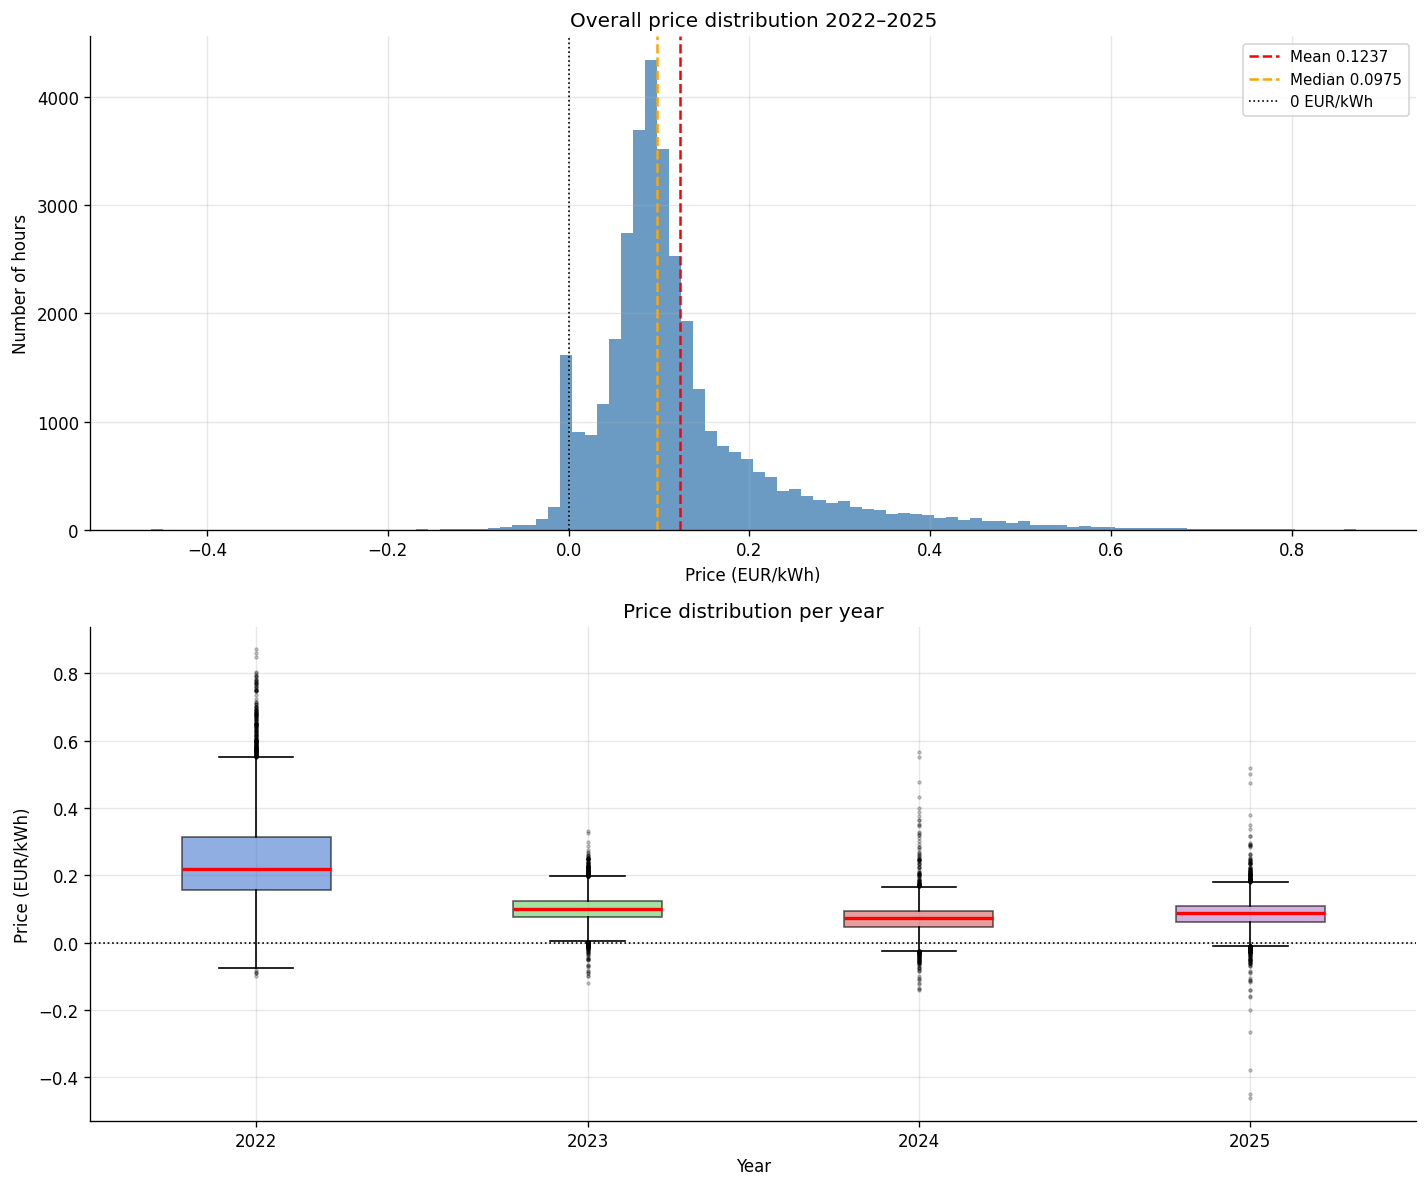

In [54]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: histogram of all hourly prices
ax = axes[0]
ax.hist(p, bins=100, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(p.mean(),   color='red',    lw=1.5, linestyle='--', label=f'Mean {p.mean():.4f}')
ax.axvline(p.median(), color='orange', lw=1.5, linestyle='--', label=f'Median {p.median():.4f}')
ax.axvline(0,          color='black',  lw=1.0, linestyle=':',  label='0 EUR/kWh')
ax.set_xlabel('Price (EUR/kWh)')
ax.set_ylabel('Number of hours')
ax.set_title('Overall price distribution 2022–2025')
ax.legend(fontsize=9)

# Bottom: box plot per year — shows median, spread and outliers
ax2 = axes[1]
groups = [prices[prices['year'] == y]['price_eur_kwh'].dropna().values for y in years]
bp = ax2.boxplot(groups, labels=years, patch_artist=True,
                 medianprops=dict(color='red', lw=2),
                 flierprops=dict(marker='.', alpha=0.3, markersize=3))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.axhline(0, color='black', lw=1, linestyle=':')
ax2.set_xlabel('Year')
ax2.set_ylabel('Price (EUR/kWh)')
ax2.set_title('Price distribution per year')

plt.tight_layout()
plt.show()

## 3. Time patterns — hour, month, weekday

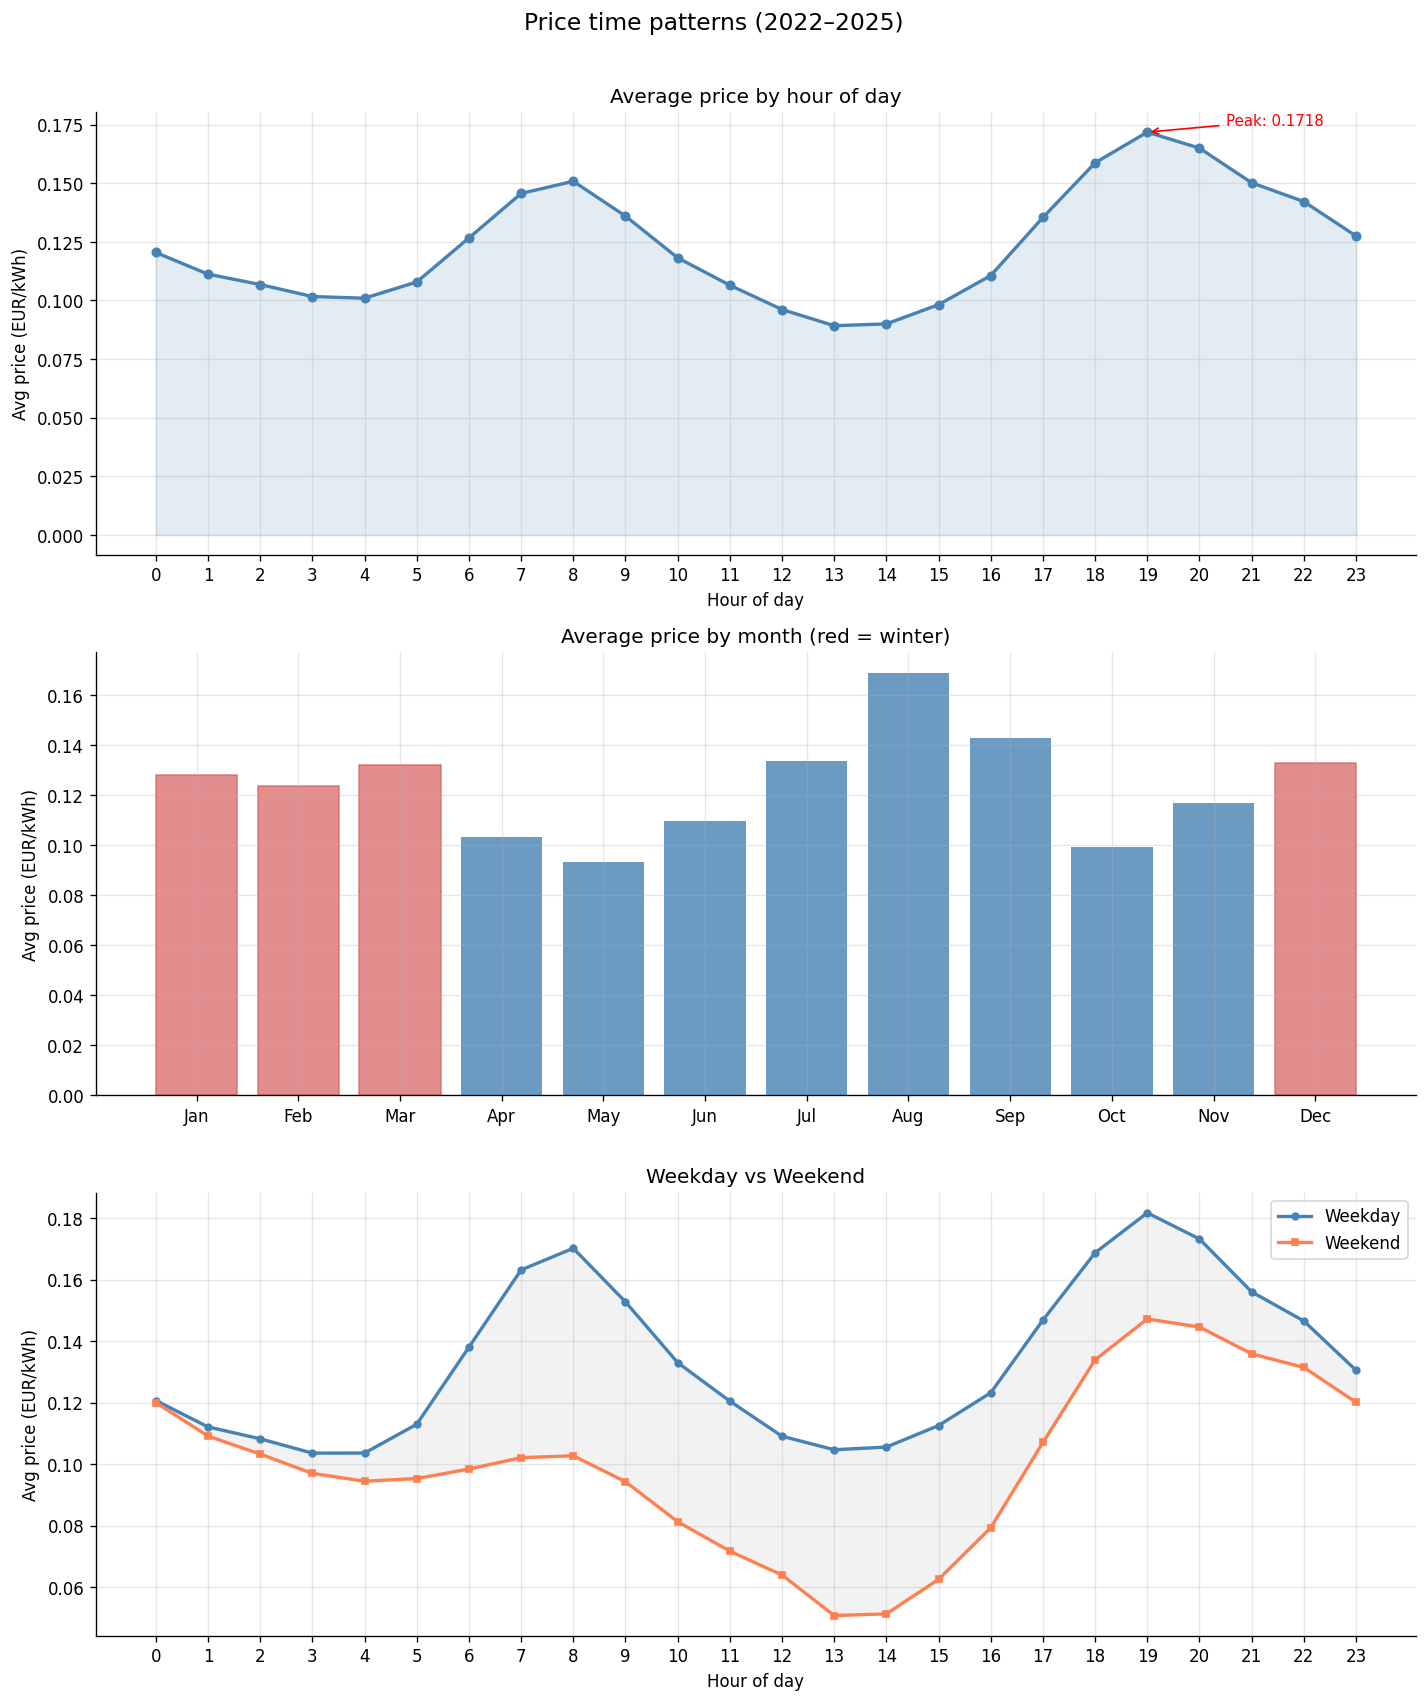

Weekday mean: 0.1332 EUR/kWh
Weekend mean: 0.0999 EUR/kWh
Difference:   0.0333 EUR/kWh  (33.4% higher on weekdays)


In [55]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

# ── Average price by hour of day ──────────────────────────────────────────────
ax = axes[0]
hourly = prices.groupby('hour')['price_eur_kwh'].mean()
ax.plot(hourly.index, hourly.values, color='steelblue', lw=2, marker='o', ms=5)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color='steelblue')
peak_h = hourly.idxmax()
ax.annotate(f'Peak: {hourly.max():.4f}',
            xy=(peak_h, hourly.max()),
            xytext=(peak_h + 1.5, hourly.max() + 0.003),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg price (EUR/kWh)')
ax.set_title('Average price by hour of day')
ax.set_xticks(range(0, 24, 1))

# ── Average price by month ─────────────────────────────────────────────────────
ax2 = axes[1]
monthly = prices.groupby('month')['price_eur_kwh'].mean()
bars = ax2.bar(range(1, 13), monthly.values, color='steelblue', alpha=0.8)
for i, m in enumerate(range(1, 13)):
    if m in WINTER:
        bars[i].set_color('#d65f5f')
        bars[i].set_alpha(0.7)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(MONTH_NAMES, fontsize=10)
ax2.set_ylabel('Avg price (EUR/kWh)')
ax2.set_title('Average price by month (red = winter)')

# ── Weekday vs Weekend hourly profile ─────────────────────────────────────────
ax3 = axes[2]
wd = prices[~prices['is_weekend']].groupby('hour')['price_eur_kwh'].mean()
we = prices[ prices['is_weekend']].groupby('hour')['price_eur_kwh'].mean()
ax3.plot(wd.index, wd.values, color='steelblue', lw=2, label='Weekday', marker='o', ms=4)
ax3.plot(we.index, we.values, color='coral',     lw=2, label='Weekend', marker='s', ms=4)
ax3.fill_between(wd.index, wd.values, we.values, alpha=0.1, color='gray')
ax3.set_xlabel('Hour of day')
ax3.set_ylabel('Avg price (EUR/kWh)')
ax3.set_title('Weekday vs Weekend')
ax3.set_xticks(range(0, 24, 1))
ax3.legend()

plt.suptitle('Price time patterns (2022–2025)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

wd_mean = prices[~prices['is_weekend']]['price_eur_kwh'].mean()
we_mean = prices[ prices['is_weekend']]['price_eur_kwh'].mean()
print(f"Weekday mean: {wd_mean:.4f} EUR/kWh")
print(f"Weekend mean: {we_mean:.4f} EUR/kWh")
print(f"Difference:   {wd_mean - we_mean:.4f} EUR/kWh  ({(wd_mean/we_mean - 1)*100:.1f}% higher on weekdays)")

## 4. Volatility — daily spread per year

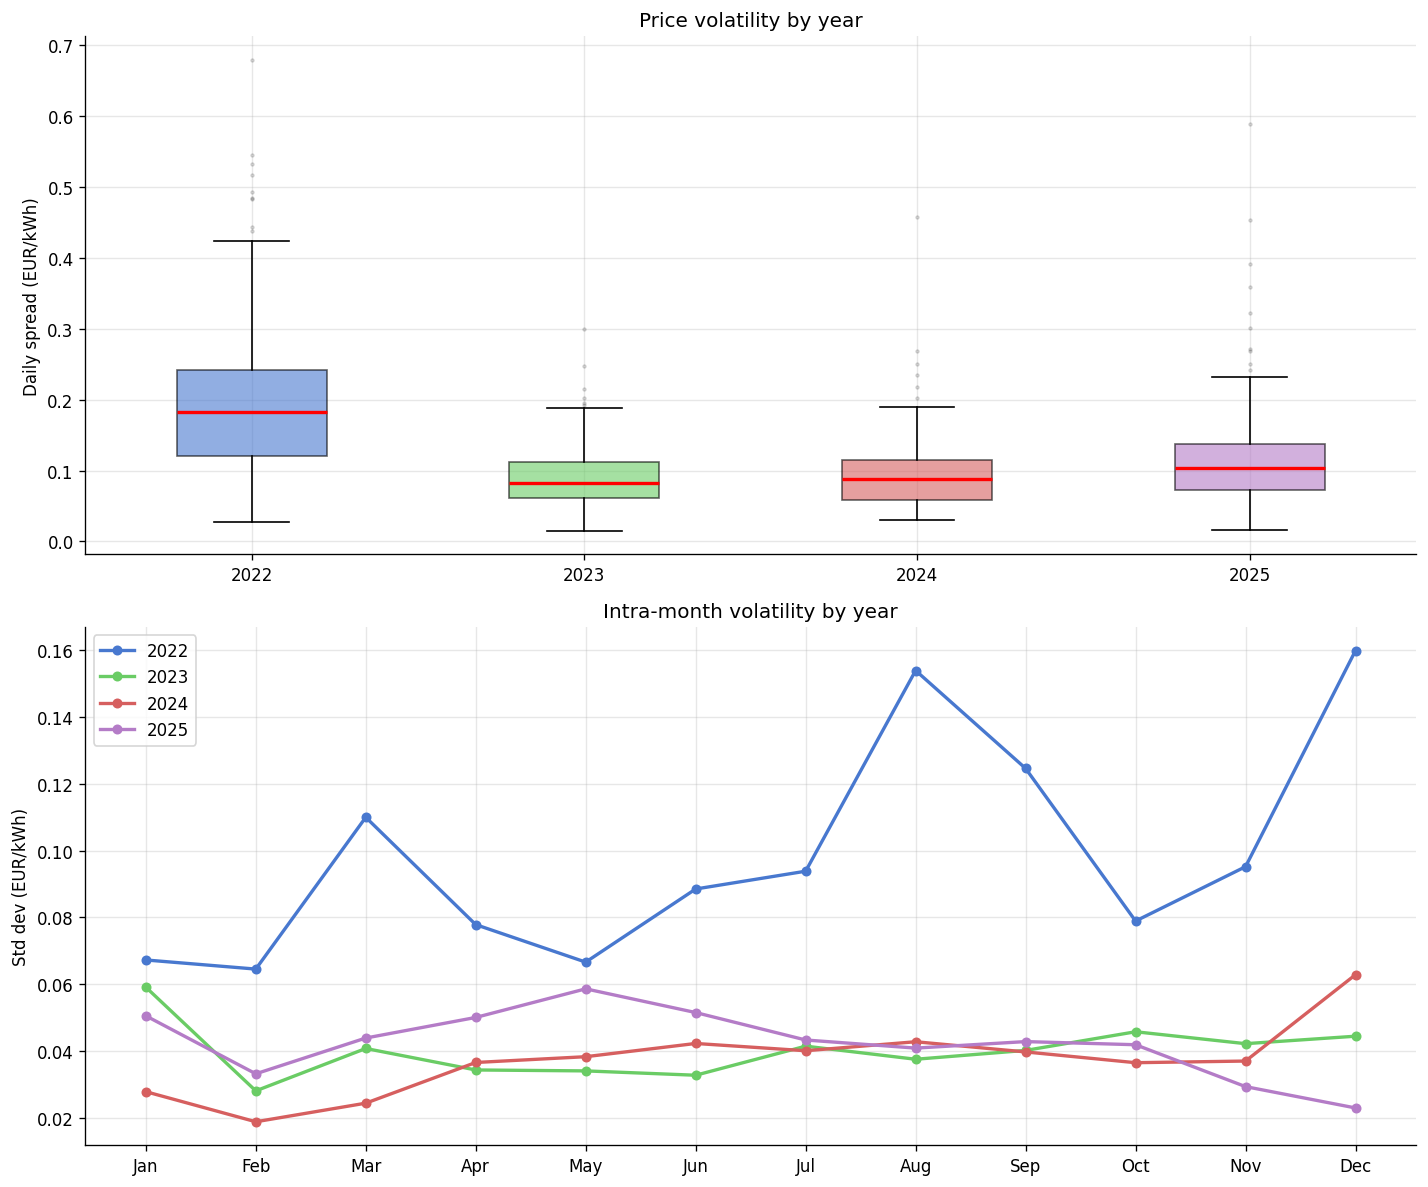

Average daily spread by year:
year
2022    0.1973
2023    0.0902
2024    0.0918
2025    0.1109


In [56]:
# Daily spread = max price - min price on that day.
# A large spread means more arbitrage opportunity for a battery.

prices['date'] = prices.index.date
daily_spread = (
    prices.groupby(['date', 'year'])['price_eur_kwh']
    .agg(spread=lambda x: x.max() - x.min())
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: how large is the daily spread in each year?
ax = axes[0]
spread_groups = [daily_spread[daily_spread['year'] == y]['spread'].values for y in years]
bp = ax.boxplot(spread_groups, labels=years, patch_artist=True,
                medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='.', alpha=0.2, markersize=3))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Daily spread (EUR/kWh)')
ax.set_title('Price volatility by year')

# Bottom: monthly std dev per year — which months are most volatile?
ax2 = axes[1]
monthly_std = prices.groupby(['year', 'month'])['price_eur_kwh'].std().unstack(0)
for yr, color in zip(years, COLORS):
    if yr in monthly_std.columns:
        ax2.plot(range(1, 13), monthly_std[yr].values,
                 marker='o', ms=5, label=str(yr), lw=2, color=color)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(MONTH_NAMES, fontsize=10)
ax2.set_ylabel('Std dev (EUR/kWh)')
ax2.set_title('Intra-month volatility by year')
ax2.legend()

plt.tight_layout()
plt.show()

print("Average daily spread by year:")
print(daily_spread.groupby('year')['spread'].mean().round(4).to_string())

## 5. Negative prices — when do they occur?

In [57]:
# Negative prices happen when supply (wind/solar) exceeds demand.
# For a battery this is a great time to charge — you get paid to consume!

neg = prices[prices['price_eur_kwh'] < 0].copy()
print(f"Total negative-price hours: {len(neg)}  ({len(neg)/len(prices)*100:.1f}%)")
print(f"Lowest price:               {neg['price_eur_kwh'].min():.4f} EUR/kWh")
print()
print("By year:")
print(neg.groupby('year').size().to_string())
print()
print("By hour of day (top 5 hours):")
print(neg.groupby('hour').size().sort_values(ascending=False).head().to_string())

Total negative-price hours: 1257  (3.6%)
Lowest price:               -0.4623 EUR/kWh

By year:
year
2022    112
2023    222
2024    404
2025    519

By hour of day (top 5 hours):
hour
14    198
13    193
15    160
12    157
11    119


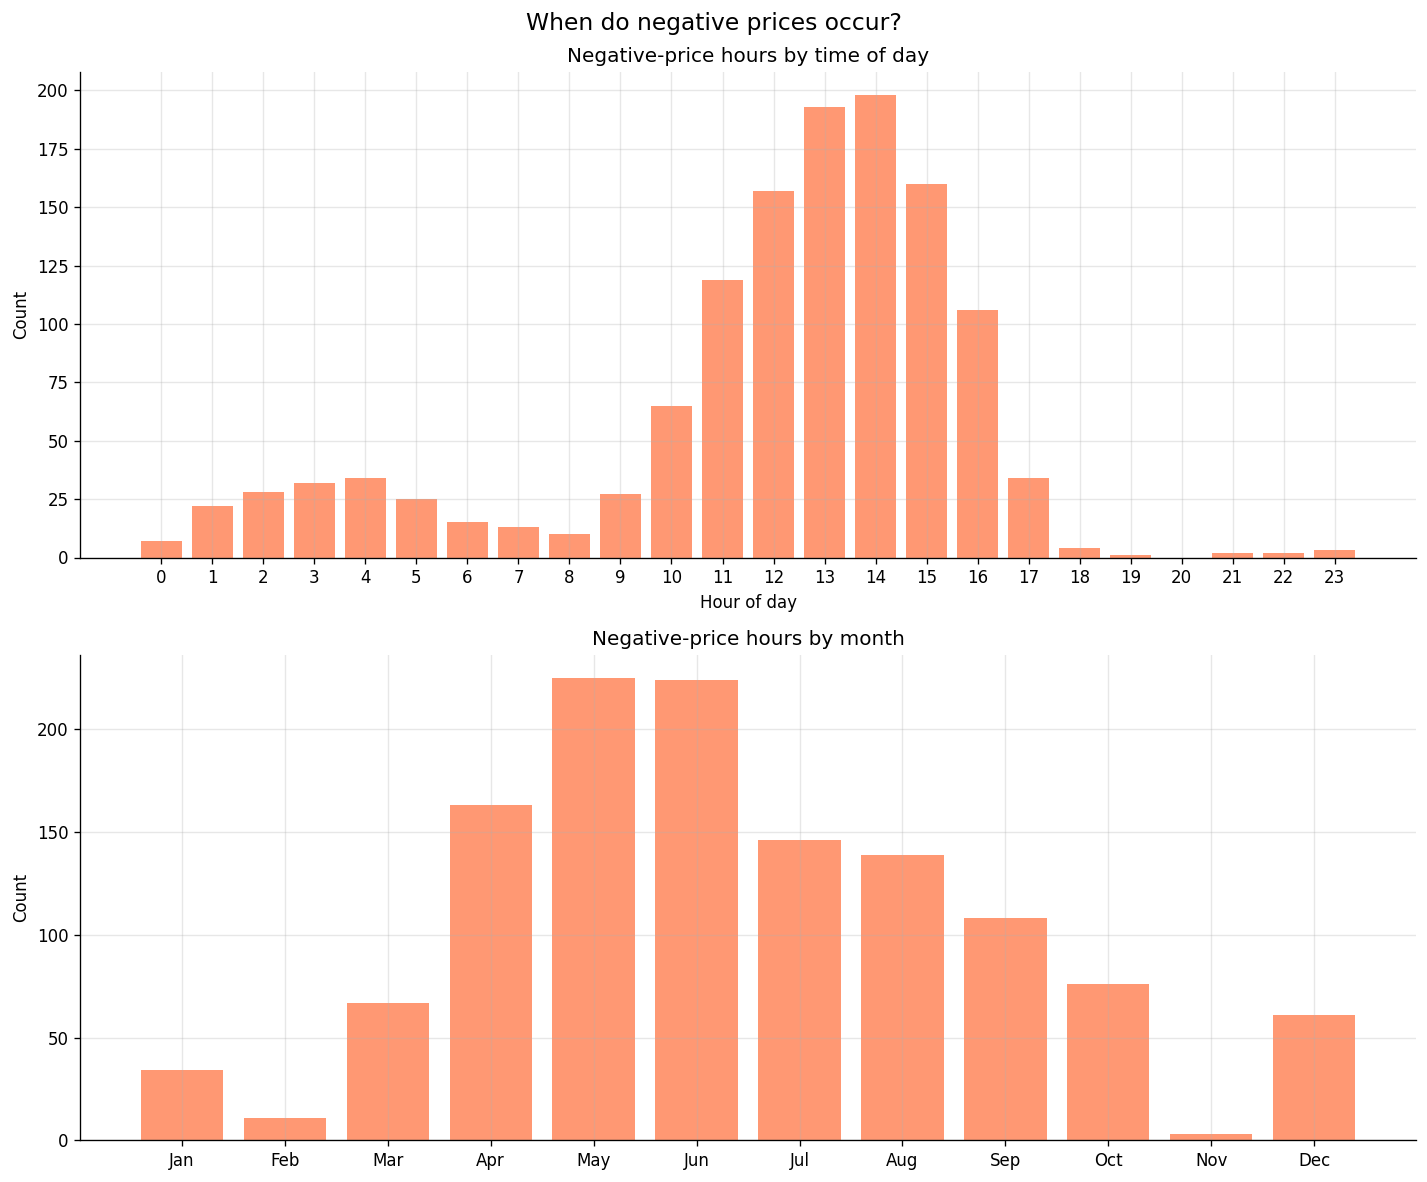

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: how are negative prices distributed across the day?
ax = axes[0]
neg_hour = neg.groupby('hour').size().reindex(range(24), fill_value=0)
ax.bar(neg_hour.index, neg_hour.values, color='coral', alpha=0.8)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Count')
ax.set_title('Negative-price hours by time of day')
ax.set_xticks(range(0, 24, 1))

# Bottom: across months
ax2 = axes[1]
neg_month = neg.groupby('month').size().reindex(range(1, 13), fill_value=0)
ax2.bar(range(1, 13), neg_month.values, color='coral', alpha=0.8)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(MONTH_NAMES, fontsize=10)
ax2.set_ylabel('Count')
ax2.set_title('Negative-price hours by month')

plt.suptitle('When do negative prices occur?', fontsize=14)
plt.tight_layout()
plt.show()

---
## 6. Consumption — basic statistics

In [59]:
c = load['consumption']
print(f"Mean:            {c.mean():.4f} kWh")
print(f"Min:             {c.min():.4f} kWh")
print(f"Max:             {c.max():.4f} kWh")
print(f"Std dev:         {c.std():.4f} kWh")
print(f"Coeff. of var:   {c.std()/c.mean()*100:.1f}%")
print(f"Annual total:    {load[load.index.year == 2022]['consumption'].sum():.0f} kWh (2022)")
print(f"Missing values:  {c.isna().sum()}")

Mean:            0.3993 kWh
Min:             0.1345 kWh
Max:             0.7367 kWh
Std dev:         0.1562 kWh
Coeff. of var:   39.1%
Annual total:    3500 kWh (2022)
Missing values:  0


## 7. Consumption — daily profile

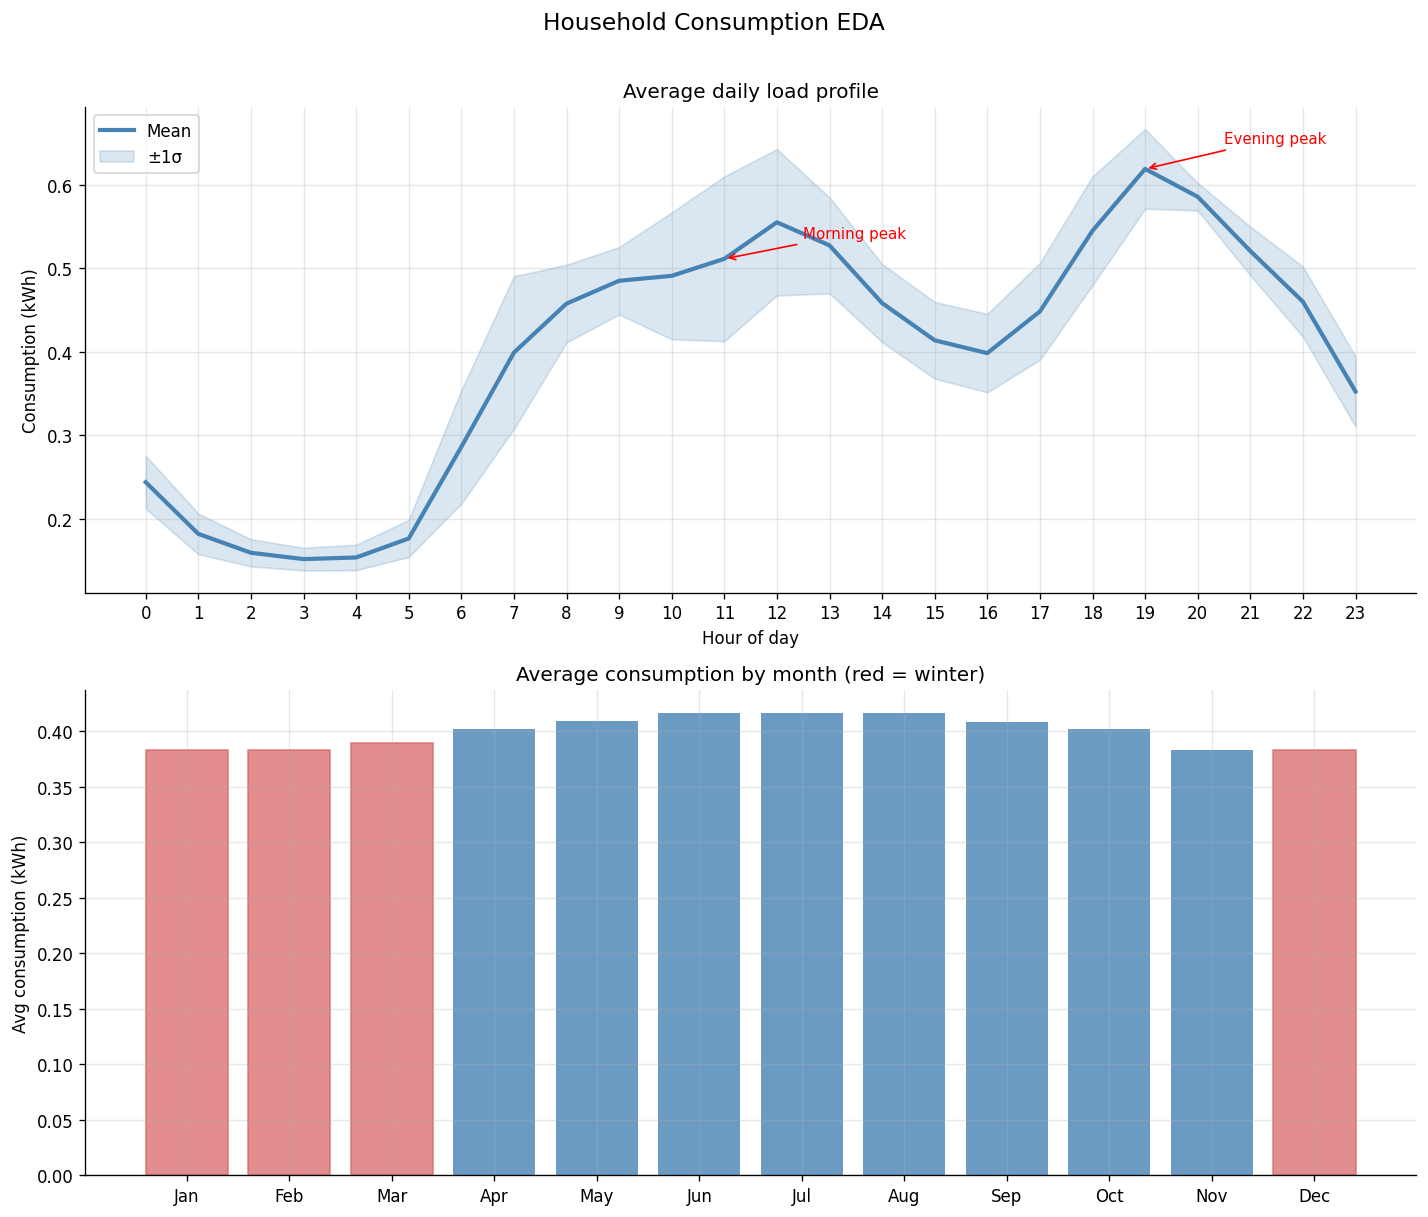

In [60]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: average consumption per hour
ax = axes[0]
hourly_load = load.groupby('hour')['consumption'].agg(['mean', 'std'])
ax.plot(hourly_load.index, hourly_load['mean'], color='steelblue', lw=2.5, label='Mean')
ax.fill_between(
    hourly_load.index,
    hourly_load['mean'] - hourly_load['std'],
    hourly_load['mean'] + hourly_load['std'],
    alpha=0.2, color='steelblue', label='±1σ'
)
morning_peak = hourly_load['mean'].iloc[6:12].idxmax()
evening_peak = hourly_load['mean'].iloc[17:22].idxmax()
for peak, label in [(morning_peak, 'Morning peak'), (evening_peak, 'Evening peak')]:
    ax.annotate(label,
                xy=(peak, hourly_load['mean'].loc[peak]),
                xytext=(peak + 1.5, hourly_load['mean'].loc[peak] * 1.05),
                arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Consumption (kWh)')
ax.set_title('Average daily load profile')
ax.set_xticks(range(0, 24, 1))
ax.legend()

# Bottom: average consumption per month
ax2 = axes[1]
monthly_load = load.groupby('month')['consumption'].mean()
bars = ax2.bar(range(1, 13), monthly_load.values, color='steelblue', alpha=0.8)
for i, m in enumerate(range(1, 13)):
    if m in WINTER:
        bars[i].set_color('#d65f5f')
        bars[i].set_alpha(0.7)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(MONTH_NAMES, fontsize=10)
ax2.set_ylabel('Avg consumption (kWh)')
ax2.set_title('Average consumption by month (red = winter)')

plt.suptitle('Household Consumption EDA', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Consumption — Winter vs Summer

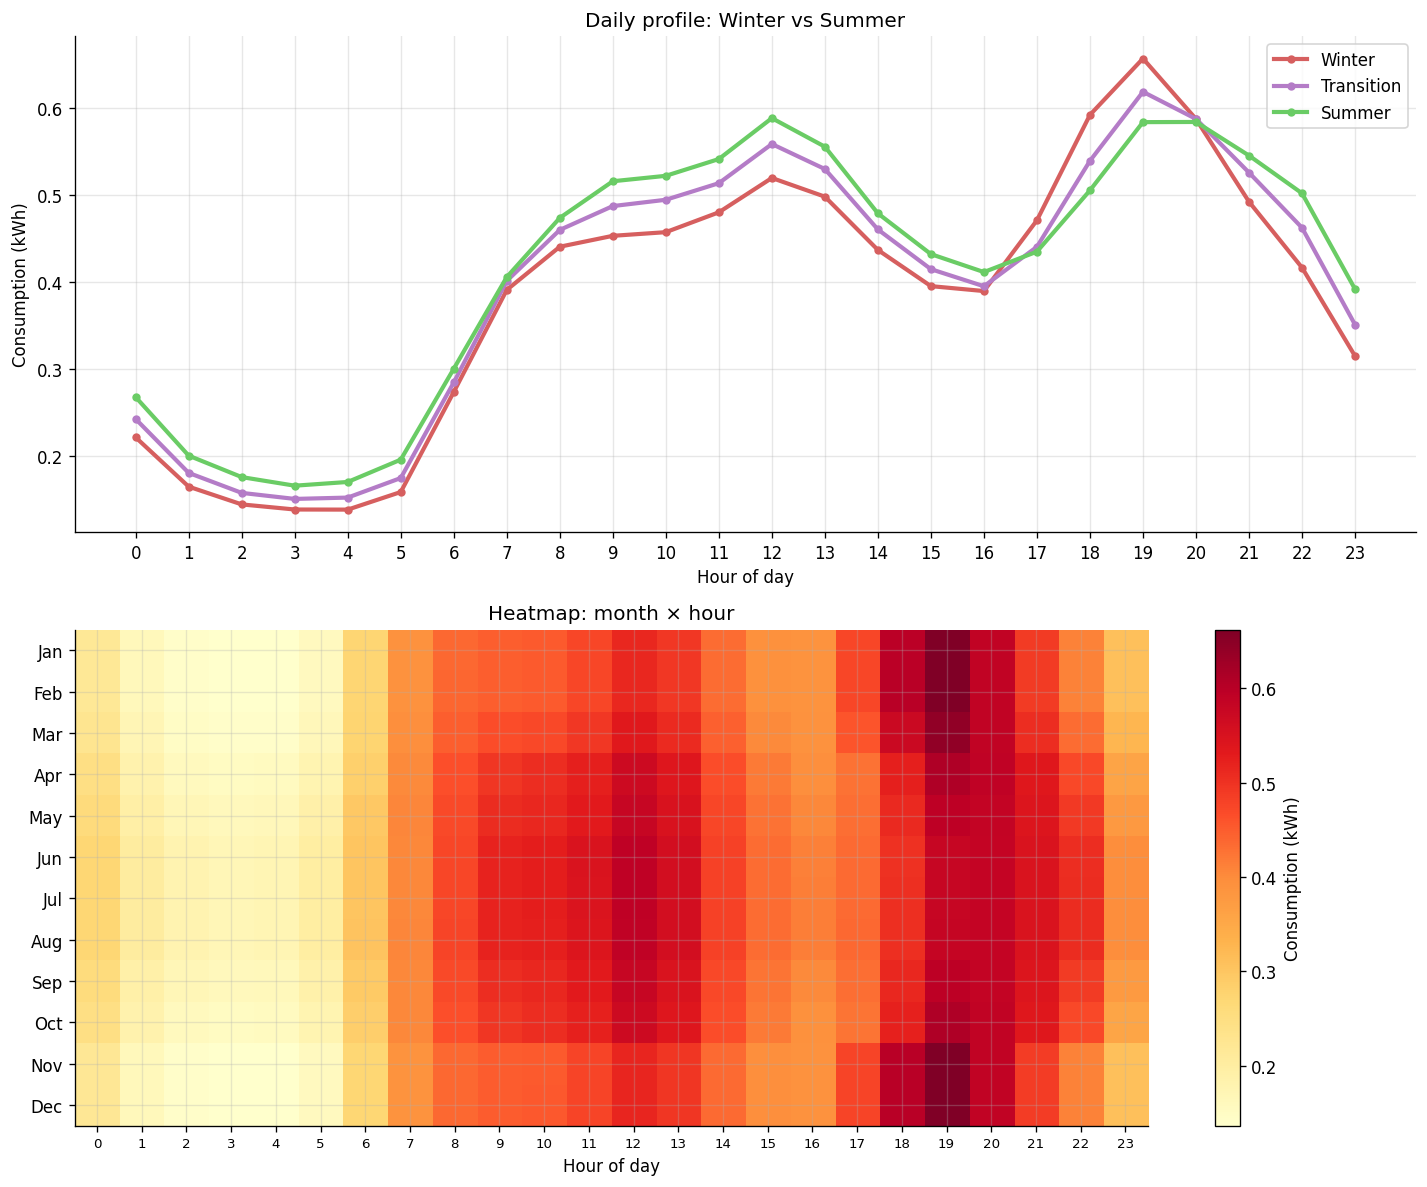

Average consumption by season:
  Winter      : 0.3844 kWh
  Transition  : 0.3991 kWh
  Summer      : 0.4143 kWh


In [61]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: seasonal hourly profiles
ax = axes[0]
SEASON_COLORS = {'Winter': '#d65f5f', 'Transition': '#b47cc7', 'Summer': '#6acc65'}
for season, color in SEASON_COLORS.items():
    profile = load[load['season'] == season].groupby('hour')['consumption'].mean()
    ax.plot(profile.index, profile.values, color=color, lw=2.5,
            label=season, marker='o', ms=4)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Consumption (kWh)')
ax.set_title('Daily profile: Winter vs Summer')
ax.set_xticks(range(0, 24, 1))
ax.legend()

# Bottom: heatmap month × hour — shows the full seasonal picture at once
ax2 = axes[1]
heatmap = load.groupby(['month', 'hour'])['consumption'].mean().unstack()
im = ax2.imshow(heatmap.values, aspect='auto', cmap='YlOrRd', origin='upper')
plt.colorbar(im, ax=ax2, label='Consumption (kWh)')
ax2.set_xticks(range(0, 24, 1))
ax2.set_xticklabels(range(24), fontsize=8)
ax2.set_yticks(range(12))
ax2.set_yticklabels(MONTH_NAMES)
ax2.set_xlabel('Hour of day')
ax2.set_title('Heatmap: month × hour')

plt.tight_layout()
plt.show()

print("Average consumption by season:")
for season in ['Winter', 'Transition', 'Summer']:
    val = load[load['season'] == season]['consumption'].mean()
    print(f"  {season:12s}: {val:.4f} kWh")

---
## 9. Price vs Consumption — joint view

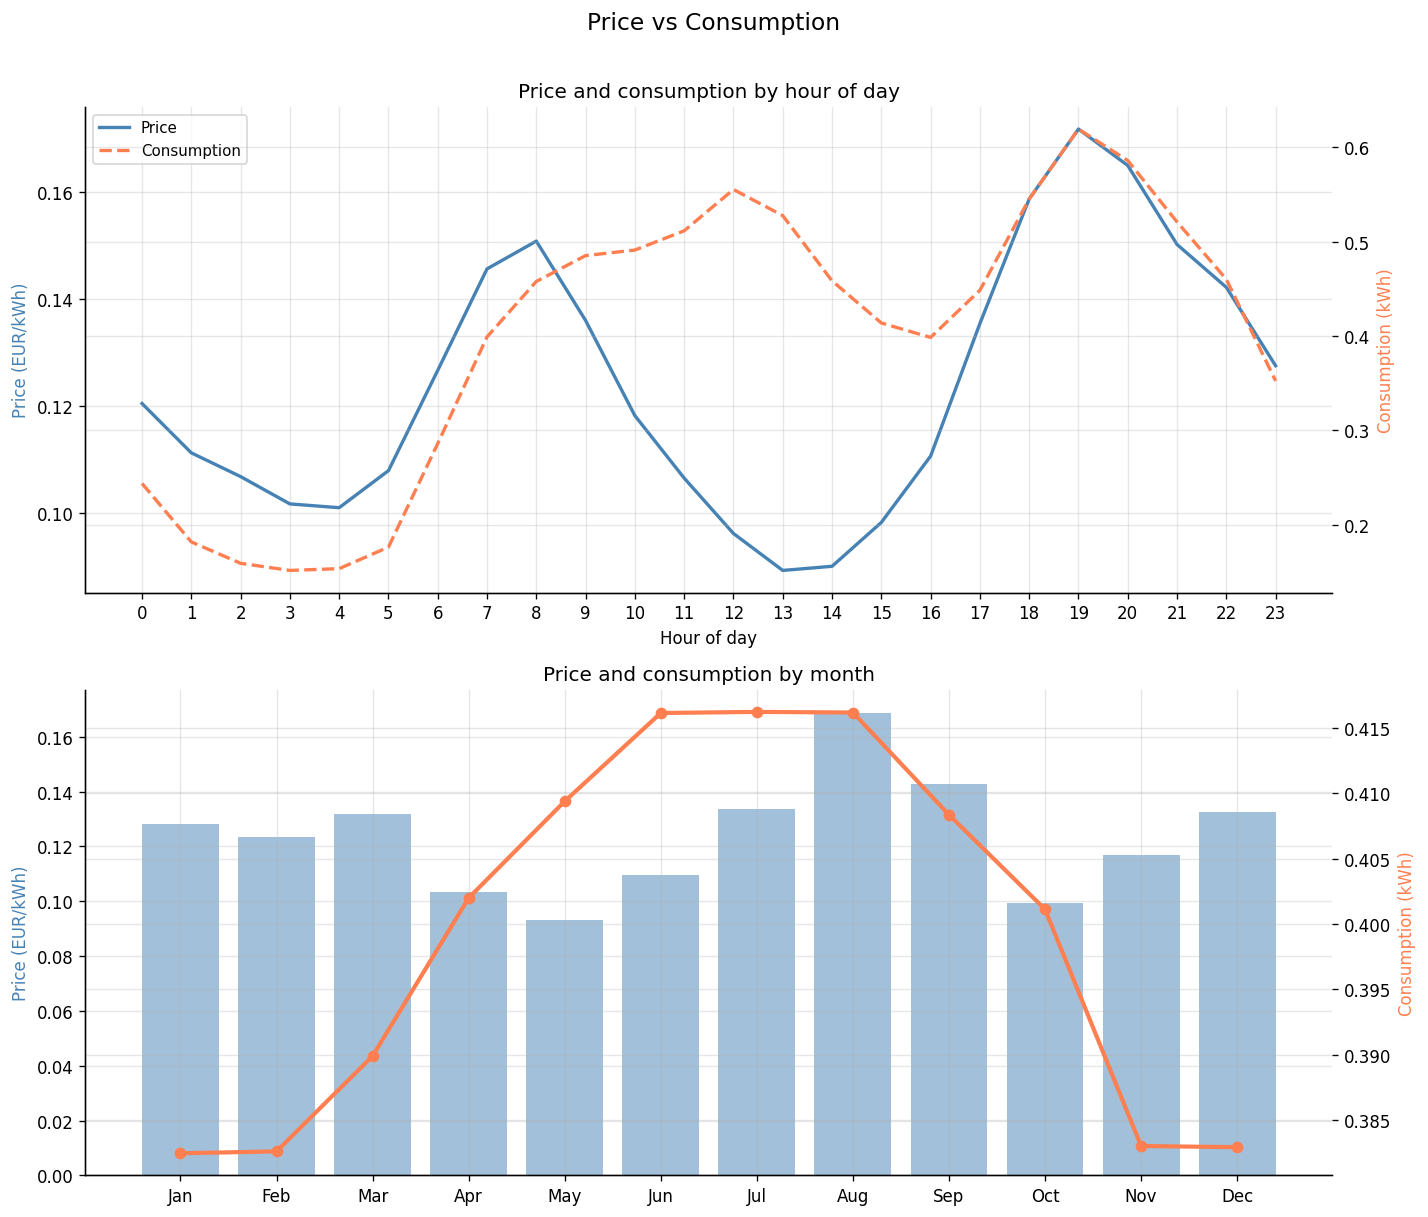

Pearson correlation (price vs consumption): 0.089


In [62]:
# Align the two datasets on a common hourly UTC-naive index
prices_naive = prices[['price_eur_kwh', 'hour', 'month']].copy()
prices_naive.index = prices_naive.index.tz_localize(None)
combined = prices_naive.join(load[['consumption']], how='inner')

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: by hour — do prices and consumption peak at the same time?
ax = axes[0]
ax_twin = ax.twinx()
ax.plot(combined.groupby('hour')['price_eur_kwh'].mean(),
        color='steelblue', lw=2, label='Price')
ax_twin.plot(combined.groupby('hour')['consumption'].mean(),
             color='coral', lw=2, linestyle='--', label='Consumption')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Price (EUR/kWh)', color='steelblue')
ax_twin.set_ylabel('Consumption (kWh)', color='coral')
ax.set_title('Price and consumption by hour of day')
ax.set_xticks(range(0, 24, 1))
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# Bottom: by month
ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.bar(range(1, 13), combined.groupby('month')['price_eur_kwh'].mean().values,
        alpha=0.5, color='steelblue', label='Price')
ax2_twin.plot(range(1, 13), combined.groupby('month')['consumption'].mean().values,
              color='coral', lw=2.5, marker='o', ms=6, label='Consumption')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(MONTH_NAMES, fontsize=10)
ax2.set_ylabel('Price (EUR/kWh)', color='steelblue')
ax2_twin.set_ylabel('Consumption (kWh)', color='coral')
ax2.set_title('Price and consumption by month')

plt.suptitle('Price vs Consumption', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

corr = combined[['price_eur_kwh', 'consumption']].corr().iloc[0, 1]
print(f"Pearson correlation (price vs consumption): {corr:.3f}")

---
## 10. Weather data — quick check

In [63]:
print(weather.describe().round(2))
print('\nMissing values:', weather.isnull().sum().to_dict())

       temperature_2m  cloud_cover  wind_speed_10m  shortwave_radiation  \
count        35040.00     35040.00        35040.00             35040.00   
mean            12.00        66.93           13.72               132.96   
std              6.79        40.01            7.02               204.70   
min             -6.65         0.00            0.00                 0.00   
25%              7.20        26.00            8.46                 0.00   
50%             11.80        96.00           12.62                 5.00   
75%             16.80       100.00           17.73               206.00   
max             37.45       100.00           51.53               891.00   

          month      hour  
count  35040.00  35040.00  
mean       6.52     11.50  
std        3.45      6.92  
min        1.00      0.00  
25%        4.00      5.75  
50%        7.00     11.50  
75%       10.00     17.25  
max       12.00     23.00  

Missing values: {'temperature_2m': 0, 'cloud_cover': 0, 'wind_speed_10m

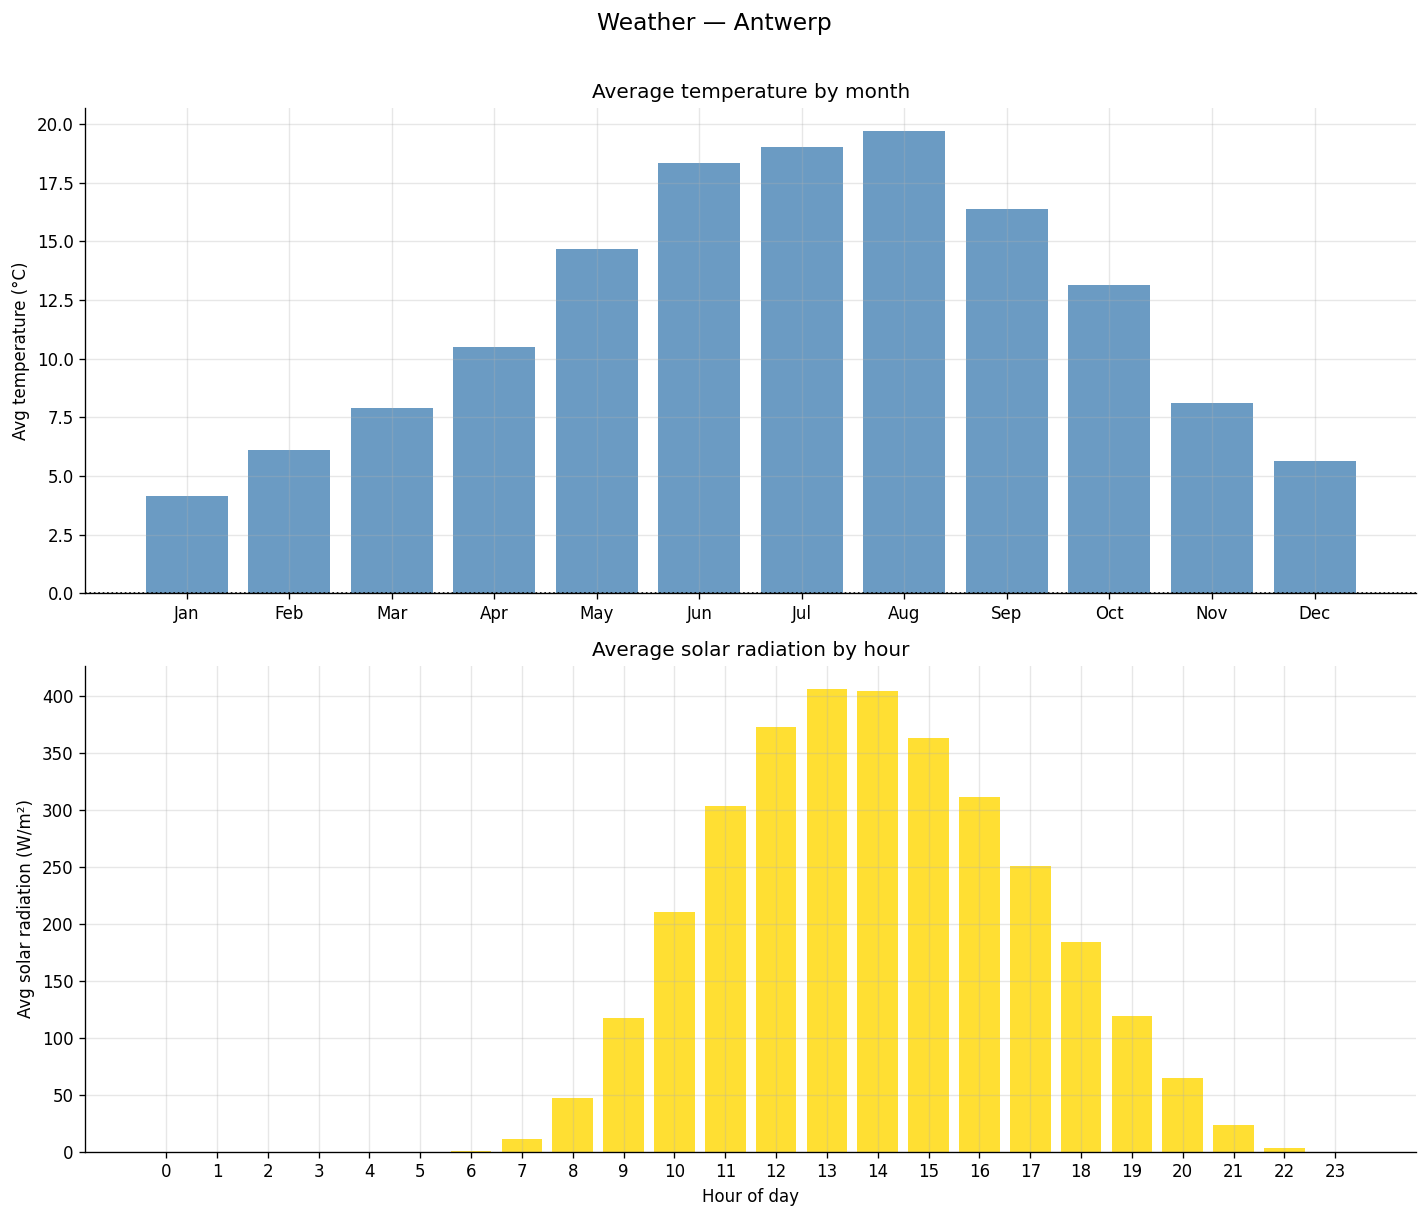

In [64]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: temperature by month
ax = axes[0]
ax.bar(range(1, 13),
       weather.groupby('month')['temperature_2m'].mean().values,
       color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=1, linestyle=':')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_NAMES, fontsize=10)
ax.set_ylabel('Avg temperature (°C)')
ax.set_title('Average temperature by month')

# Bottom: solar radiation by hour — useful because solar causes negative prices
ax2 = axes[1]
solar = weather.groupby('hour')['shortwave_radiation'].mean()
ax2.bar(solar.index, solar.values, color='gold', alpha=0.8)
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Avg solar radiation (W/m²)')
ax2.set_title('Average solar radiation by hour')
ax2.set_xticks(range(0, 24, 1))

plt.suptitle('Weather — Antwerp', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 11. Key findings

**Prices:**
- **2022 crisis year**: highest mean price and largest daily spread → greatest potential battery savings.
- **Daily profile**: evening peak (~17–19h) > morning peak (~8–9h). Night (2–5h) is cheapest → ideal charging window.
- **Seasonality**: winter months are more expensive than summer.
- **Weekdays vs weekends**: weekdays are notably more expensive (industrial demand).
- **Negative prices**: occur mainly midday (solar surplus) and on weekends → optimal charging opportunity.

**Consumption (H0 profile):**
- Classic double-peak: morning (~8h) and evening (~19h).
- Winter consumption is higher than summer (heating, less daylight).
- Consumption peaks align with price peaks → discharging the battery at these moments is the key arbitrage.

**For battery optimisation:**
- **Charge**: overnight (0–6h) or during negative prices.
- **Discharge**: evening peak (17–21h) at high prices.
- Highest expected savings: 2022-like price years and winter months.

---
## 12. Export — save cleaned data for optimization

In [65]:
from pathlib import Path

out = Path(DATA + 'prepared')
out.mkdir(exist_ok=True)

# Save prices in UTC so loading is unambiguous across DST transitions
prices_save = prices[['price_eur_kwh']].copy()
prices_save.index = prices_save.index.tz_convert('UTC')
prices_save.to_csv(out / 'prices_clean.csv')

# Save load (timezone-naive index — no conversion needed)
load[['consumption']].to_csv(out / 'load_clean.csv')

# Save weather without derived helper columns (month, hour)
weather[['temperature_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']].to_csv(
    out / 'weather_clean.csv'
)

print("Cleaned data saved to Data/prepared/")
print(f"  prices_clean.csv  : {len(prices):,} rows  ({prices.index.min().date()} → {prices.index.max().date()})")
print(f"  load_clean.csv    : {len(load):,} rows  ({load.index.min().date()} → {load.index.max().date()})")
print(f"  weather_clean.csv : {len(weather):,} rows  ({weather.index.min().date()} → {weather.index.max().date()})")

Cleaned data saved to Data/prepared/
  prices_clean.csv  : 35,040 rows  (2022-01-01 → 2025-12-30)
  load_clean.csv    : 35,040 rows  (2022-01-01 → 2025-12-30)
  weather_clean.csv : 35,040 rows  (2022-01-01 → 2025-12-30)
